**1. import Libraries**

In [240]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

# Boosting Models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

**2.Upload Dataset**

In [241]:
train=pd.read_csv('cargo_dwell_time_train.csv')
pd.set_option('display.max_columns', None)
val=pd.read_csv('cargo_dwell_time_validation.csv')
test=pd.read_csv('cargo_dwell_time_test.csv')
train

,shipment_id,cargo_weight,shipment_priority,shc,customs_status,inspection_required,clearance_type,documentation_status,payment_status,consignee_name,consignee_behavior,staff_availability,truck_availability,packaging_condition,warehouse_load_percentage,flight_delay_hours,arrival_datetime,release_datetime,dwell_time_hours
0,SHIP_106443,1272.15,Low,GEN,Hold,1,Automatic,Missing,Pending,MedSupply International,Cooperative,67,Available,Good,57.05,6.67,2024-01-01 22:37:00,2024-01-05 08:37:00,82
1,SHIP_112985,2627.16,Medium,GEN,Pending,1,Automatic,Incomplete,Pending,Secure Freight Systems,Average,22,Available,Good,49.46,23.77,2023-12-31 22:42:00,2024-01-03 05:42:00,55
2,SHIP_108351,2410.81,Low,GEN,Under Inspection,0,Automatic,Complete,Paid,Skyline Traders,Average,40,Available,Good,69.81,22.13,2023-12-30 23:32:00,2024-01-01 09:32:00,34
3,SHIP_115599,4864.96,Medium,VAL,Pending,0,Manual,Incomplete,Pending,DHL Logistics,Average,92,Available,Good,49.36,22.56,2023-12-30 23:39:00,2024-01-02 00:39:00,49
4,SHIP_119367,2749.27,Critical,EAT,Under Inspection,0,Manual,Missing,Paid,FreshFoods Exports,Cooperative,76,Not Available,Good,83.35,18.94,2024-01-02 06:45:00,2024-01-04 15:45:00,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,SHIP_114130,4644.16,Medium,PER,Under Inspection,1,Manual,Incomplete,Overdue,Global Electronics Pvt Ltd,Cooperative,55,Not Available,Good,67.10,0.47,2025-05-24 21:43:00,2025-05-29 06:43:00,105
13996,SHIP_110819,1711.11,Medium,AVI,Hold,1,Automatic,Missing,Overdue,DHL Logistics,Average,33,Available,Good,49.72,10.34,2025-05-21 18:20:00,2025-05-25 18:20:00,96
13997,SHIP_100849,3206.63,Critical,EAT,Hold,0,Automatic,Complete,Pending,ABC Pharma Ltd,Delayed Response,67,Available,Good,87.62,12.61,2025-05-22 14:47:00,2025-05-24 01:47:00,35
13998,SHIP_101637,1200.72,Medium,VAL,Hold,0,Manual,Complete,Paid,AeroTech Solutions,Delayed Response,41,Available,Good,49.94,14.90,2025-05-20 10:53:00,2025-05-21 18:53:00,32


In [ ]:
#modify datetime features

train['arrival_datetime'] = pd.to_datetime(
    train['arrival_datetime']
)

val['arrival_datetime'] = pd.to_datetime(
    val['arrival_datetime']
)

test['arrival_datetime'] = pd.to_datetime(
    test['arrival_datetime']
)
train['release_datetime'] = pd.to_datetime(
    train['release_datetime']
)

val['release_datetime'] = pd.to_datetime(
    val['release_datetime']
)

test['release_datetime'] = pd.to_datetime(
    test['release_datetime']
    
)

train['arrival_month'] = train[
    'arrival_datetime'
].dt.month

val['arrival_month'] = val[
    'arrival_datetime'
].dt.month

test['arrival_month'] = test[
    'arrival_datetime'
].dt.month

train['arrival_day'] = train[
    'arrival_datetime'
].dt.day

val['arrival_day'] = val[
    'arrival_datetime'
].dt.day

test['arrival_day'] = test[
    'arrival_datetime'
].dt.day

train['arrival_hour'] = train[
    'arrival_datetime'
].dt.hour

val['arrival_hour'] = val[
    'arrival_datetime'
].dt.hour

test['arrival_hour'] = test[
    'arrival_datetime'
].dt.hour

train['arrival_weekday'] = train[
    'arrival_datetime'
].dt.weekday

val['arrival_weekday'] = val[
    'arrival_datetime'
].dt.weekday

test['arrival_weekday'] = test[
    'arrival_datetime'
].dt.weekday
train['is_weekend'] = train[
    'arrival_weekday'
].isin([5,6]).astype(int)

val['is_weekend'] = val[
    'arrival_weekday'
].isin([5,6]).astype(int)

test['is_weekend'] = test[
    'arrival_weekday'
].isin([5,6]).astype(int)

**3.Exploratary Data Analysis**

In [244]:
# above_120 = train[
#     train['dwell_time_hours'] > 120
# ]

# print("Count :", len(above_120))

# above_120.head(20)

3.1 Basic Checkups

In [245]:
print(f"shape of the dataset: {train.shape}")
print("\n")
print(train.info())


shape of the dataset: (14000, 24)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   shipment_id                14000 non-null  object        
 1   cargo_weight               14000 non-null  float64       
 2   shipment_priority          14000 non-null  object        
 3   shc                        14000 non-null  object        
 4   customs_status             14000 non-null  object        
 5   inspection_required        14000 non-null  int64         
 6   clearance_type             14000 non-null  object        
 7   documentation_status       14000 non-null  object        
 8   payment_status             14000 non-null  object        
 9   consignee_name             14000 non-null  object        
 10  consignee_behavior         14000 non-null  object        
 11  staff_availability         1400

In [246]:
print(train.isnull().sum())

shipment_id                  0
cargo_weight                 0
shipment_priority            0
shc                          0
customs_status               0
inspection_required          0
clearance_type               0
documentation_status         0
payment_status               0
consignee_name               0
consignee_behavior           0
staff_availability           0
truck_availability           0
packaging_condition          0
warehouse_load_percentage    0
flight_delay_hours           0
arrival_datetime             0
release_datetime             0
dwell_time_hours             0
arrival_month                0
arrival_day                  0
arrival_hour                 0
arrival_weekday              0
is_weekend                   0
dtype: int64


3.2 Charts for understanding the Dataset Features

3.2.1 Distribution of Dwell Time Hours

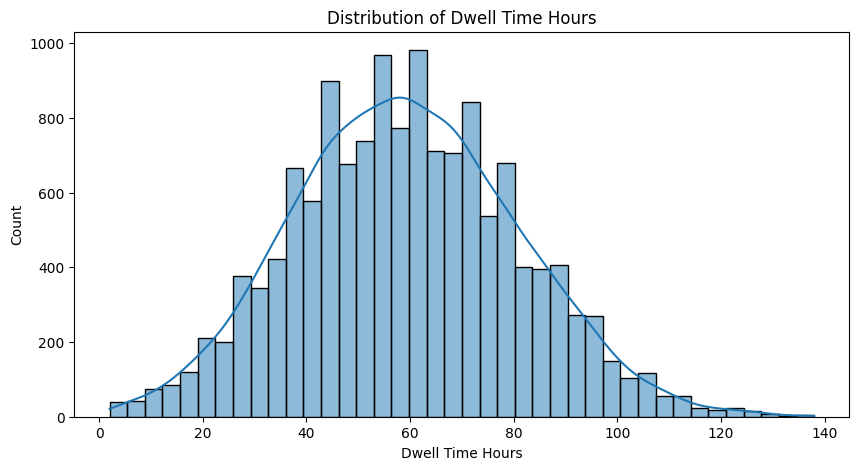

In [247]:
plt.figure(figsize=(10,5))
sns.histplot(train['dwell_time_hours'], bins=40, kde=True)
plt.title("Distribution of Dwell Time Hours")
plt.xlabel("Dwell Time Hours")
plt.show()

3.2.2 charts for Customs Status vs Dwell Time

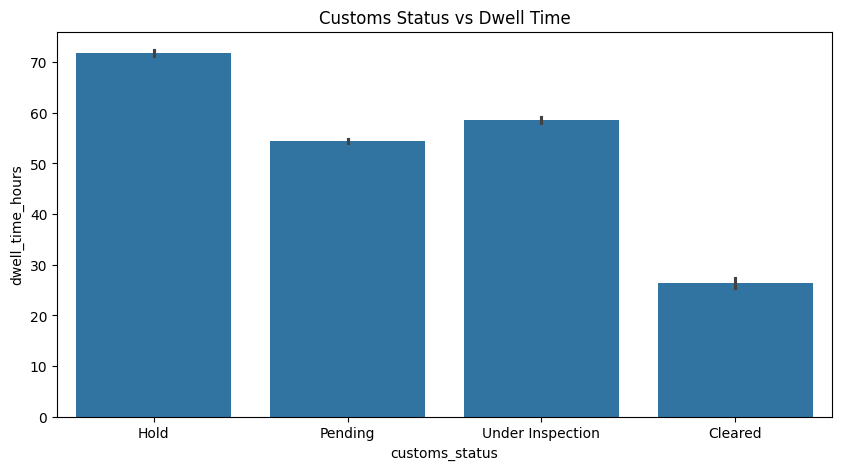

In [248]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='customs_status',
    y='dwell_time_hours',
    data=train
)

plt.title("Customs Status vs Dwell Time")

plt.show()

3.2.3 charts for Payment vs Average Dwell Time

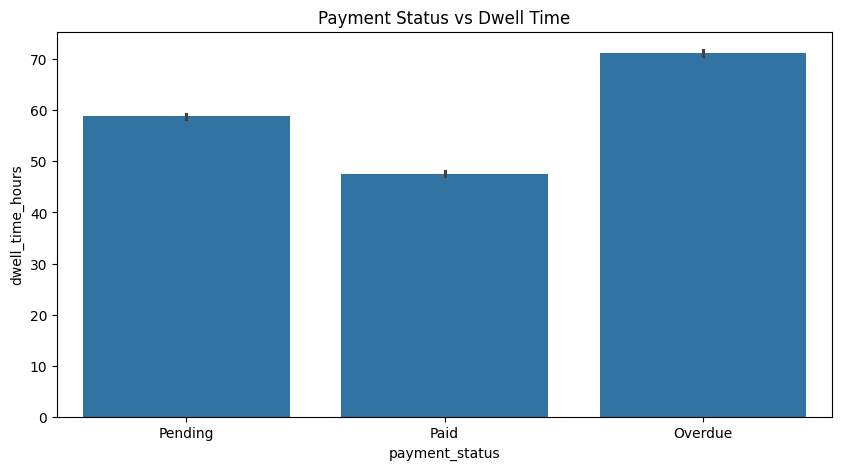

In [249]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='payment_status',
    y='dwell_time_hours',
    data=train
)

plt.title("Payment Status vs Dwell Time")

plt.show()

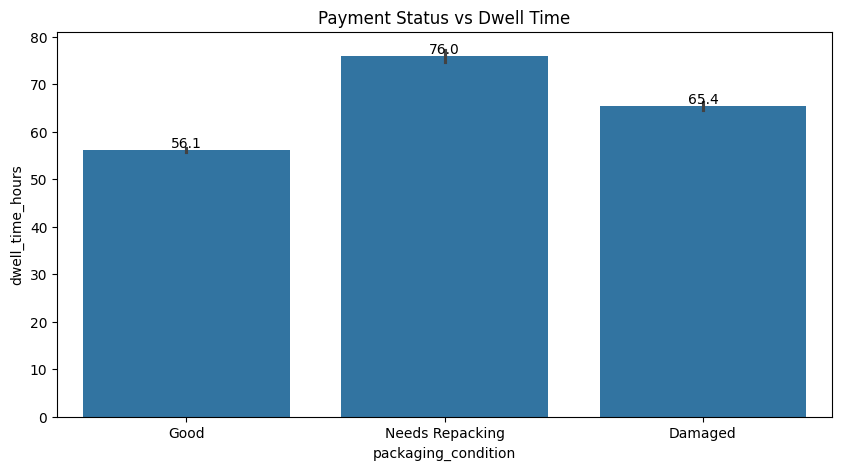

In [250]:
plt.figure(figsize=(10,5))

ax=sns.barplot(
    x='packaging_condition',
    y='dwell_time_hours',
    data=train
)
for p in ax.patches:

    value = p.get_height()

    ax.annotate(
        f'{value:.1f}',
        
        (
            p.get_x() + p.get_width()/2,
            value
        ),
        
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Payment Status vs Dwell Time")

plt.show()

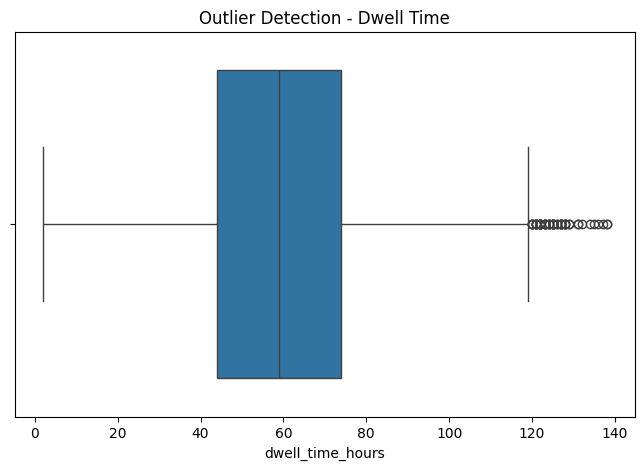

In [251]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=train['dwell_time_hours']
)

plt.title("Outlier Detection - Dwell Time")

plt.show()

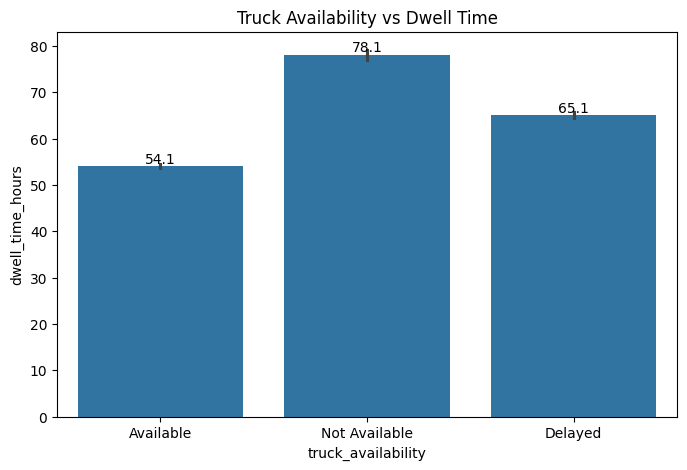

In [252]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x='truck_availability',
    y='dwell_time_hours',
    data=train
)
for p in ax.patches:

    value = p.get_height()

    ax.annotate(
        f'{value:.1f}',
        
        (
            p.get_x() + p.get_width()/2,
            value
        ),
        
        ha='center',
        va='bottom',
        fontsize=10
    )


plt.title(
    "Truck Availability vs Dwell Time"
)

plt.show()

is_weekend
0    58.479196
1    61.074861
Name: dwell_time_hours, dtype: float64


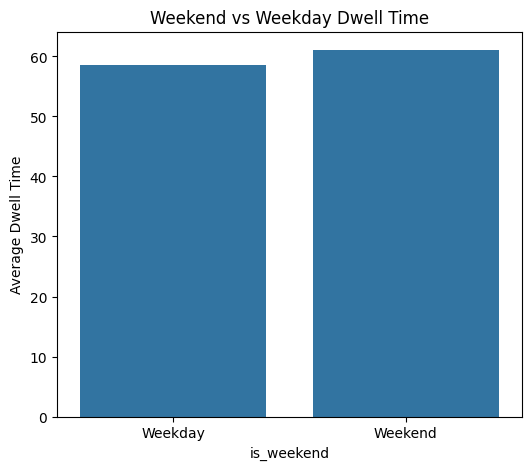

In [253]:
weekend_dwell = train.groupby(
    'is_weekend')['dwell_time_hours'].mean()
print(weekend_dwell)
plt.figure(figsize=(6,5))
sns.barplot(x=weekend_dwell.index,y=weekend_dwell.values)
plt.xticks([0,1],['Weekday','Weekend'])
plt.title('Weekend vs Weekday Dwell Time')
plt.ylabel('Average Dwell Time')
plt.show()

**4. Feature splitting**

In [254]:
# Define target column
target = 'dwell_time_hours'

# Drop unnecessary columns
drop_columns = [
    'shipment_id',
    'arrival_datetime',
    'release_datetime',
    'dwell_time_hours'
]

#Feature and target separation
X_train = train.drop(columns=drop_columns)
y_train = train[target]

X_val = val.drop(columns=drop_columns)
y_val = val[target]

X_test = test.drop(columns=drop_columns)
y_test = test[target]

In [255]:
X_train

,cargo_weight,shipment_priority,shc,customs_status,inspection_required,clearance_type,documentation_status,payment_status,consignee_name,consignee_behavior,staff_availability,truck_availability,packaging_condition,warehouse_load_percentage,flight_delay_hours,arrival_month,arrival_day,arrival_hour,arrival_weekday,is_weekend
0,1272.15,Low,GEN,Hold,1,Automatic,Missing,Pending,MedSupply International,Cooperative,67,Available,Good,57.05,6.67,1,1,22,0,0
1,2627.16,Medium,GEN,Pending,1,Automatic,Incomplete,Pending,Secure Freight Systems,Average,22,Available,Good,49.46,23.77,12,31,22,6,1
2,2410.81,Low,GEN,Under Inspection,0,Automatic,Complete,Paid,Skyline Traders,Average,40,Available,Good,69.81,22.13,12,30,23,5,1
3,4864.96,Medium,VAL,Pending,0,Manual,Incomplete,Pending,DHL Logistics,Average,92,Available,Good,49.36,22.56,12,30,23,5,1
4,2749.27,Critical,EAT,Under Inspection,0,Manual,Missing,Paid,FreshFoods Exports,Cooperative,76,Not Available,Good,83.35,18.94,1,2,6,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,4644.16,Medium,PER,Under Inspection,1,Manual,Incomplete,Overdue,Global Electronics Pvt Ltd,Cooperative,55,Not Available,Good,67.10,0.47,5,24,21,5,1
13996,1711.11,Medium,AVI,Hold,1,Automatic,Missing,Overdue,DHL Logistics,Average,33,Available,Good,49.72,10.34,5,21,18,2,0
13997,3206.63,Critical,EAT,Hold,0,Automatic,Complete,Pending,ABC Pharma Ltd,Delayed Response,67,Available,Good,87.62,12.61,5,22,14,3,0
13998,1200.72,Medium,VAL,Hold,0,Manual,Complete,Paid,AeroTech Solutions,Delayed Response,41,Available,Good,49.94,14.90,5,20,10,1,0


4.1 store for catboost algorithm

In [256]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

In [257]:
X_train_cat

,cargo_weight,shipment_priority,shc,customs_status,inspection_required,clearance_type,documentation_status,payment_status,consignee_name,consignee_behavior,staff_availability,truck_availability,packaging_condition,warehouse_load_percentage,flight_delay_hours,arrival_month,arrival_day,arrival_hour,arrival_weekday,is_weekend
0,1272.15,Low,GEN,Hold,1,Automatic,Missing,Pending,MedSupply International,Cooperative,67,Available,Good,57.05,6.67,1,1,22,0,0
1,2627.16,Medium,GEN,Pending,1,Automatic,Incomplete,Pending,Secure Freight Systems,Average,22,Available,Good,49.46,23.77,12,31,22,6,1
2,2410.81,Low,GEN,Under Inspection,0,Automatic,Complete,Paid,Skyline Traders,Average,40,Available,Good,69.81,22.13,12,30,23,5,1
3,4864.96,Medium,VAL,Pending,0,Manual,Incomplete,Pending,DHL Logistics,Average,92,Available,Good,49.36,22.56,12,30,23,5,1
4,2749.27,Critical,EAT,Under Inspection,0,Manual,Missing,Paid,FreshFoods Exports,Cooperative,76,Not Available,Good,83.35,18.94,1,2,6,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,4644.16,Medium,PER,Under Inspection,1,Manual,Incomplete,Overdue,Global Electronics Pvt Ltd,Cooperative,55,Not Available,Good,67.10,0.47,5,24,21,5,1
13996,1711.11,Medium,AVI,Hold,1,Automatic,Missing,Overdue,DHL Logistics,Average,33,Available,Good,49.72,10.34,5,21,18,2,0
13997,3206.63,Critical,EAT,Hold,0,Automatic,Complete,Pending,ABC Pharma Ltd,Delayed Response,67,Available,Good,87.62,12.61,5,22,14,3,0
13998,1200.72,Medium,VAL,Hold,0,Manual,Complete,Paid,AeroTech Solutions,Delayed Response,41,Available,Good,49.94,14.90,5,20,10,1,0


**5.Encoding the Categorical Value**

In [258]:
categorical_cols = X_train.select_dtypes(
    include='object'
).columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col]
    )

    X_val[col] = le.transform(
        X_val[col]
    )

    X_test[col] = le.transform(
        X_test[col]
    )

    # Store encoder
    label_encoders[col] = le

**6. Model Building**

6.1 Linear Regression

In [259]:
lr_model = LinearRegression(fit_intercept=True)
lr_model.fit(X_train,y_train)

# Validation prediction
y_val_pred_lr = lr_model.predict(X_val)
print("Linear Regression Trained Successfully!")

Linear Regression Trained Successfully!


In [260]:
mae_lr = mean_absolute_error(y_val,y_val_pred_lr)
mse_lr = mean_squared_error(y_val,y_val_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_val,y_val_pred_lr)

print("MAE :", round(mae_lr, 2))
print("MSE :", round(mse_lr, 2))
print("RMSE :", round(rmse_lr, 2))
print("R2 Score :", round(r2_lr, 4))

MAE : 10.81
MSE : 180.12
RMSE : 13.42
R2 Score : 0.5946


6.2 Decision Tree

In [261]:
# param_grid = {
#     'max_depth': [5, 10, 15, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5]
#     'criterion': [
#         'squared_error',
#         'friedman_mse'
#     ]
# }
# dt_grid = GridSearchCV(
#     estimator=DecisionTreeRegressor(
#         random_state=42
#     ),
#     param_grid=param_grid,
#     cv=3,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=1
# )

# dt_grid.fit(X_train,y_train)
# print("Best Parameters :")
# print(dt_grid.best_params_)
# print("\nBest R2 Score :")
# print(dt_grid.best_score_)

In [262]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42,
)

dt_model.fit(X_train,y_train)
y_val_pred_dt = dt_model.predict(X_val)
print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [263]:
mae_dt = mean_absolute_error(y_val,y_val_pred_dt)
mse_dt = mean_squared_error(y_val,y_val_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_val,y_val_pred_dt)

print("MAE :", round(mae_dt, 2))
print("MSE :", round(mse_dt, 2))
print("RMSE :", round(rmse_dt, 2))
print("R2 Score :", round(r2_dt, 4))

MAE : 5.66
MSE : 52.13
RMSE : 7.22
R2 Score : 0.8827


6.3 Random Forest


In [264]:
# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [10, 15, 20],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2],
#     'max_features': ['sqrt']
# }

# rf_grid = GridSearchCV(
#     estimator=RandomForestRegressor(
#         random_state=42,
#         n_jobs=-1
#     ),
#     param_grid=param_grid,
#     cv=3,
#     scoring='r2',
#     verbose=1,
#     n_jobs=-1
# )
# rf_grid.fit(X_train,y_train)

# print("Best Parameters :")
# print(rf_grid.best_params_)
# print("\nBest Cross Validation R2 :")
# print(rf_grid.best_score_)

In [265]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_model.fit(X_train,y_train)
y_val_pred_rf = rf_model.predict(X_val)
print("Random Forest Model Trained Successfully!")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    1.9s


Random Forest Model Trained Successfully!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.0s finished


In [266]:
mae_rf = mean_absolute_error(y_val,y_val_pred_rf)
mse_rf = mean_squared_error(y_val,y_val_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

print("MAE :", round(mae_rf, 2))
print("MSE :", round(mse_rf, 2))
print("RMSE :", round(rmse_rf, 2))
print("R2 Score :", round(r2_rf, 4))

MAE : 5.15
MSE : 42.53
RMSE : 6.52
R2 Score : 0.9043


6.4 XGBoost 

In [267]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'n_estimators': [100, 200],
#     'max_depth': [4, 6, 8],
#     'learning_rate': [0.05, 0.1],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }
# xgb_grid = GridSearchCV(
#     estimator=XGBRegressor(
#         random_state=42,
#         objective='reg:squarederror'
#     ),
#     param_grid=param_grid,
#     scoring='r2',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )

# xgb_grid.fit(
#     X_train,
#     y_train
# )

# print("Best Parameters :")
# print(xgb_grid.best_params_)
# print("\nBest Cross Validation R2 :")
# print(xgb_grid.best_score_)

In [268]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train,y_train)
y_val_pred_xgb = xgb_model.predict(X_val)
print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [269]:
mae_xgb = mean_absolute_error(y_val,y_val_pred_xgb)
mse_xgb = mean_squared_error(y_val,y_val_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, y_val_pred_xgb)

print("MAE :", round(mae_xgb, 2))
print("MSE :", round(mse_xgb, 2))
print("RMSE :", round(rmse_xgb, 2))
print("R2 Score :", round(r2_xgb, 4))

MAE : 4.61
MSE : 33.0
RMSE : 5.74
R2 Score : 0.9257


6.5 CAT Boost


In [270]:
# cat_features = X_train_cat.select_dtypes(
#     include='object'
# ).columns.tolist()

# param_grid = {
#     'iterations': [200, 500],
#     'learning_rate': [0.03, 0.05, 0.1],
#     'depth': [6, 8, 10]
# }

# cat_grid = GridSearchCV(
#     estimator=CatBoostRegressor(
#         loss_function='RMSE',
#         verbose=0,
#         random_seed=42
#     ),

#     param_grid=param_grid,
#     scoring='r2',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# cat_grid.fit(X_train_cat,y_train,
#     cat_features=cat_features
# )
# print(cat_grid.best_params_)
# print(cat_grid.best_score_)

In [271]:
cat_features = X_train_cat.select_dtypes(
    include='object'
).columns.tolist()

cat_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train_cat,y_train,
    cat_features=cat_features,
    eval_set=(X_val_cat,y_val)
)

y_val_pred_cat = cat_model.predict(
    X_val_cat
)

print("CatBoost Model Trained Successfully!")

0:	learn: 0.1304532	test: 0.1314318	best: 0.1314318 (0)	total: 42.2ms	remaining: 8.4s
100:	learn: 0.9271069	test: 0.9267353	best: 0.9267353 (100)	total: 4.3s	remaining: 4.21s
199:	learn: 0.9311833	test: 0.9271315	best: 0.9272290 (170)	total: 9.48s	remaining: 0us

bestTest = 0.9272290271
bestIteration = 170

Shrink model to first 171 iterations.
CatBoost Model Trained Successfully!


In [272]:
mae_cat = mean_absolute_error(y_val,y_val_pred_cat)
mse_cat = mean_squared_error(y_val,y_val_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_val,y_val_pred_cat)

print("MAE :", round(mae_cat, 2))
print("MSE :", round(mse_cat, 2))
print("RMSE :", round(rmse_cat, 2))
print("R2 Score :", round(r2_cat, 4))

MAE : 4.55
MSE : 32.33
RMSE : 5.69
R2 Score : 0.9272


6.6 Extra Trees

In [273]:
# param_grid = {
#     'n_estimators': [200, 300],
#     'max_depth': [10, 15, 20],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }
# et_grid = GridSearchCV(
#     estimator=ExtraTreesRegressor(
#         random_state=42,
#         n_jobs=-1
#     ),
#     param_grid=param_grid,
#     scoring='r2',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )
# et_grid.fit(X_train, y_train)

# print(et_grid.best_params_)
# print(et_grid.best_score_)

In [274]:
et_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train, y_train)
y_val_pred_et = et_model.predict(X_val)

print("ExtraTrees Model Trained Successfully!")

ExtraTrees Model Trained Successfully!


In [275]:
mae_et = mean_absolute_error(y_val,y_val_pred_et)
mse_et = mean_squared_error(y_val,y_val_pred_et)
rmse_et = np.sqrt(mse_et)
r2_et = r2_score(y_val,y_val_pred_et)

print("MAE :", round(mae_et, 2))
print("MSE :", round(mse_et, 2))
print("RMSE :", round(rmse_et, 2))
print("R2 Score :", round(r2_et, 4))

MAE : 5.14
MSE : 41.57
RMSE : 6.45
R2 Score : 0.9064


6.7 Lightgbm

In [276]:
# param_grid = {
#     'n_estimators': [200, 300, 500],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'max_depth': [6, 8, 10, 12],
#     'subsample': [0.6, 0.8, 1.0]
# }

# lgbm_grid = GridSearchCV(
#     estimator=LGBMRegressor(
#         random_state=42),
#     param_grid=param_grid,
#     scoring='r2',
#     cv=3,
#     verbose=1,
#     n_jobs=-1
# )
# lgbm_grid.fit(X_train, y_train)

# print(lgbm_grid.best_params_)
# print(lgbm_grid.best_score_)

In [277]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.8,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)
y_val_pred_lgbm = lgbm_model.predict(X_val)

print("LightGBM Model Trained Successfully!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 968
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 20
[LightGBM] [Info] Start training from score 59.212286
LightGBM Model Trained Successfully!


In [278]:
mae_lgbm = mean_absolute_error(y_val,y_val_pred_lgbm)
mse_lgbm = mean_squared_error(y_val,y_val_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_val,y_val_pred_lgbm)

print("MAE :", round(mae_lgbm, 2))
print("MSE :", round(mse_lgbm, 2))
print("RMSE :", round(rmse_lgbm, 2))
print("R2 Score :", round(r2_lgbm, 4))

MAE : 4.6
MSE : 33.05
RMSE : 5.75
R2 Score : 0.9256


**7. Compare the Models**

In [279]:
model_results = pd.DataFrame({
    'Model': ['Linear Regression','Decision Tree','Random Forest','XGBoost','CatBoost','ExtraTrees','LightGBM'],
    'R2 Score': [r2_lr,r2_dt,r2_rf,r2_xgb,r2_cat,r2_et,r2_lgbm],
    'MAE':[mae_lr,mae_dt,mae_rf, mae_xgb, mae_cat, mae_et, mae_lgbm],
    'RMSE': [rmse_lr,rmse_dt,rmse_rf,rmse_xgb,rmse_cat,rmse_et,rmse_lgbm]
})
model_results = model_results.sort_values(
    by='R2 Score',
    ascending=False
)
print(model_results)

               Model  R2 Score        MAE       RMSE
4           CatBoost  0.927229   4.549325   5.686104
3            XGBoost  0.925717   4.612432   5.744884
6           LightGBM  0.925607   4.604423   5.749141
5         ExtraTrees  0.906438   5.138550   6.447425
2      Random Forest  0.904269   5.148809   6.521705
1      Decision Tree  0.882660   5.659229   7.220367
0  Linear Regression  0.594604  10.813080  13.420703


7.1 Test the model


In [280]:
y_test_pred = cat_model.predict(
    X_test_cat
)

In [281]:
mae = mean_absolute_error(y_test,y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

print("Test MAE :", round(mae, 2))
print("Test MSE :", round(mse, 2))
print("Test RMSE :", round(rmse, 2))
print("Test R2 Score :", round(r2, 4))

Test MAE : 4.6
Test MSE : 33.95
Test RMSE : 5.83
Test R2 Score : 0.9242


7.2 Feature Importance


In [282]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train_cat.columns,
    'Importance': cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                      Feature  Importance
7              payment_status   21.366894
6        documentation_status   20.077982
3              customs_status   17.020559
11         truck_availability   16.648046
4         inspection_required   13.665523
12        packaging_condition    8.656162
1           shipment_priority    2.092004
9          consignee_behavior    0.052134
15              arrival_month    0.052030
0                cargo_weight    0.047485
14         flight_delay_hours    0.047260
17               arrival_hour    0.045508
13  warehouse_load_percentage    0.042716
10         staff_availability    0.041948
16                arrival_day    0.041623
8              consignee_name    0.034243
18            arrival_weekday    0.025611
5              clearance_type    0.020930
2                         shc    0.019281
19                 is_weekend    0.002061


7.3 Feature Importance Chart

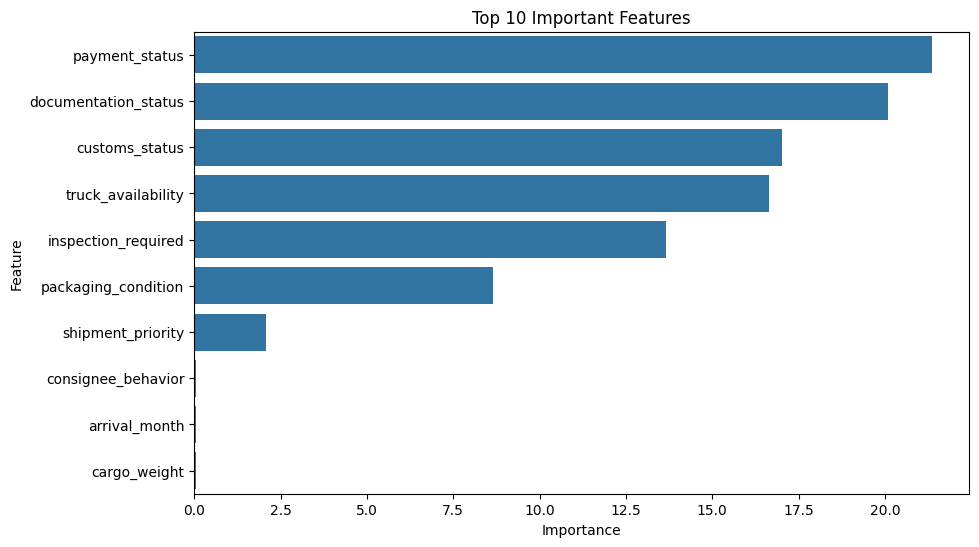

In [283]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

7.4 Save the Model

In [284]:
import joblib

joblib.dump(
    cat_model,
    "cargo_dwell_time_catboost_model.pkl"
)
print("Model Saved Successfully!")

Model Saved Successfully!


In [285]:
feature_names = X_train_cat.columns.tolist()
joblib.dump(feature_names,"feature_names.pkl")

['feature_names.pkl']

In [286]:
X_train_cat.columns.tolist()

['cargo_weight',
 'shipment_priority',
 'shc',
 'customs_status',
 'inspection_required',
 'clearance_type',
 'documentation_status',
 'payment_status',
 'consignee_name',
 'consignee_behavior',
 'staff_availability',
 'truck_availability',
 'packaging_condition',
 'warehouse_load_percentage',
 'flight_delay_hours',
 'arrival_month',
 'arrival_day',
 'arrival_hour',
 'arrival_weekday',
 'is_weekend']